---
title: Multiclass
author: "Deepika Agarwal"
format:
  html:
    embed-resources: true
echo: true
---



Our dataset consists of clinical data from patients who entered the hospital complaining of chest pain ("angina") during exercise.  The information collected includes:

* `age` : Age of the patient

* `sex` : Sex of the patient

* `cp` : Chest Pain type

    + Value 0: asymptomatic
    + Value 1: typical angina
    + Value 2: atypical angina
    + Value 3: non-anginal pain
   
    
* `trtbps` : resting blood pressure (in mm Hg)

* `chol` : cholesterol in mg/dl fetched via BMI sensor

* `restecg` : resting electrocardiographic results

    + Value 0: normal
    + Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    + Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

* `thalach` : maximum heart rate achieved during exercise

* `output` : the doctor's diagnosis of whether the patient is at risk for a heart attack
    + 0 = not at risk of heart attack
    + 1 = at risk of heart attack

In [115]:
## library imports here
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
import matplotlib.pyplot as plt
from plotnine import *

In [116]:
ha = pd.read_csv("https://www.dropbox.com/s/aohbr6yb9ifmc8w/heart_attack.csv?dl=1")

## Q1: Natural Multiclass Models

Fit a multiclass KNN, Decision Tree, and LDA for the heart disease data; this time predicting the type of chest pain (categories 0 - 3) that a patient experiences.  For the decision tree, plot the fitted tree, and interpret the first couple splits.


In [117]:
X = ha.drop(["cp", "output"], axis = 1)
y = ha["cp"]

In [118]:
X

,age,sex,trtbps,chol,restecg,thalach
0,63,1,145,233,0,150
1,37,1,130,250,1,187
2,56,1,120,236,1,178
3,57,0,120,354,1,163
4,57,1,140,192,1,148
...,...,...,...,...,...,...
268,59,1,164,176,0,90
269,57,0,140,241,1,123
270,45,1,110,264,1,132
271,68,1,144,193,1,141


Identify categorical and numerical variables in the dataset for appropriate preprocessing

In [119]:
categorical_cols = ['sex', 'restecg']
numeric_cols = ['age', 'trtbps', 'chol', 'thalach']

In [120]:
ct = ColumnTransformer(
    [
        ("dummify",
         OneHotEncoder(drop='first',
                       sparse_output=False,
                       handle_unknown='ignore'),
         categorical_cols),

        ("standardize",
         StandardScaler(),
         numeric_cols)
    ],
    remainder="passthrough"
).set_output(transform="pandas")

In [121]:
ha['cp'].value_counts(normalize=True)

cp
0    0.468864
2    0.296703
1    0.161172
3    0.073260
Name: proportion, dtype: float64

**Since dataset is imbalanced, we will use stratified KFolds**

In [122]:
folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 321)

### Model 1: kNN

In [123]:
# KNN pipeline
knn_pipeline = Pipeline(
    [("preprocessing", ct),
     ("knn", KNeighborsClassifier())]
)

knn_pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'restecg']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('knn', KNeighborsClassifier())])

In [124]:
knn_score = cross_val_score(knn_pipeline, X, y,
                            cv = folds, scoring = "f1_macro").mean()
knn_score

np.float64(0.26547199020884876)

### Model 2: Decision Tree

In [125]:
# Decision Tree Pipeline
dt_pipeline = Pipeline(
  [("preprocessing", ct),
  ("decision_tree", DecisionTreeClassifier(random_state=321))]
)

dt_pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'restecg']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('decision_tree', DecisionTreeClassifier(random_state=321))])

In [126]:
dt_score = cross_val_score(dt_pipeline, X, y,
                            cv = folds, scoring = "f1_macro").mean()
dt_score

np.float64(0.26347157181333597)

In [127]:
dt_pipeline.named_steps['preprocessing'].get_feature_names_out()

array(['dummify__sex_1', 'dummify__restecg_1', 'dummify__restecg_2', 'standardize__age',
       'standardize__trtbps', 'standardize__chol', 'standardize__thalach'], dtype=object)

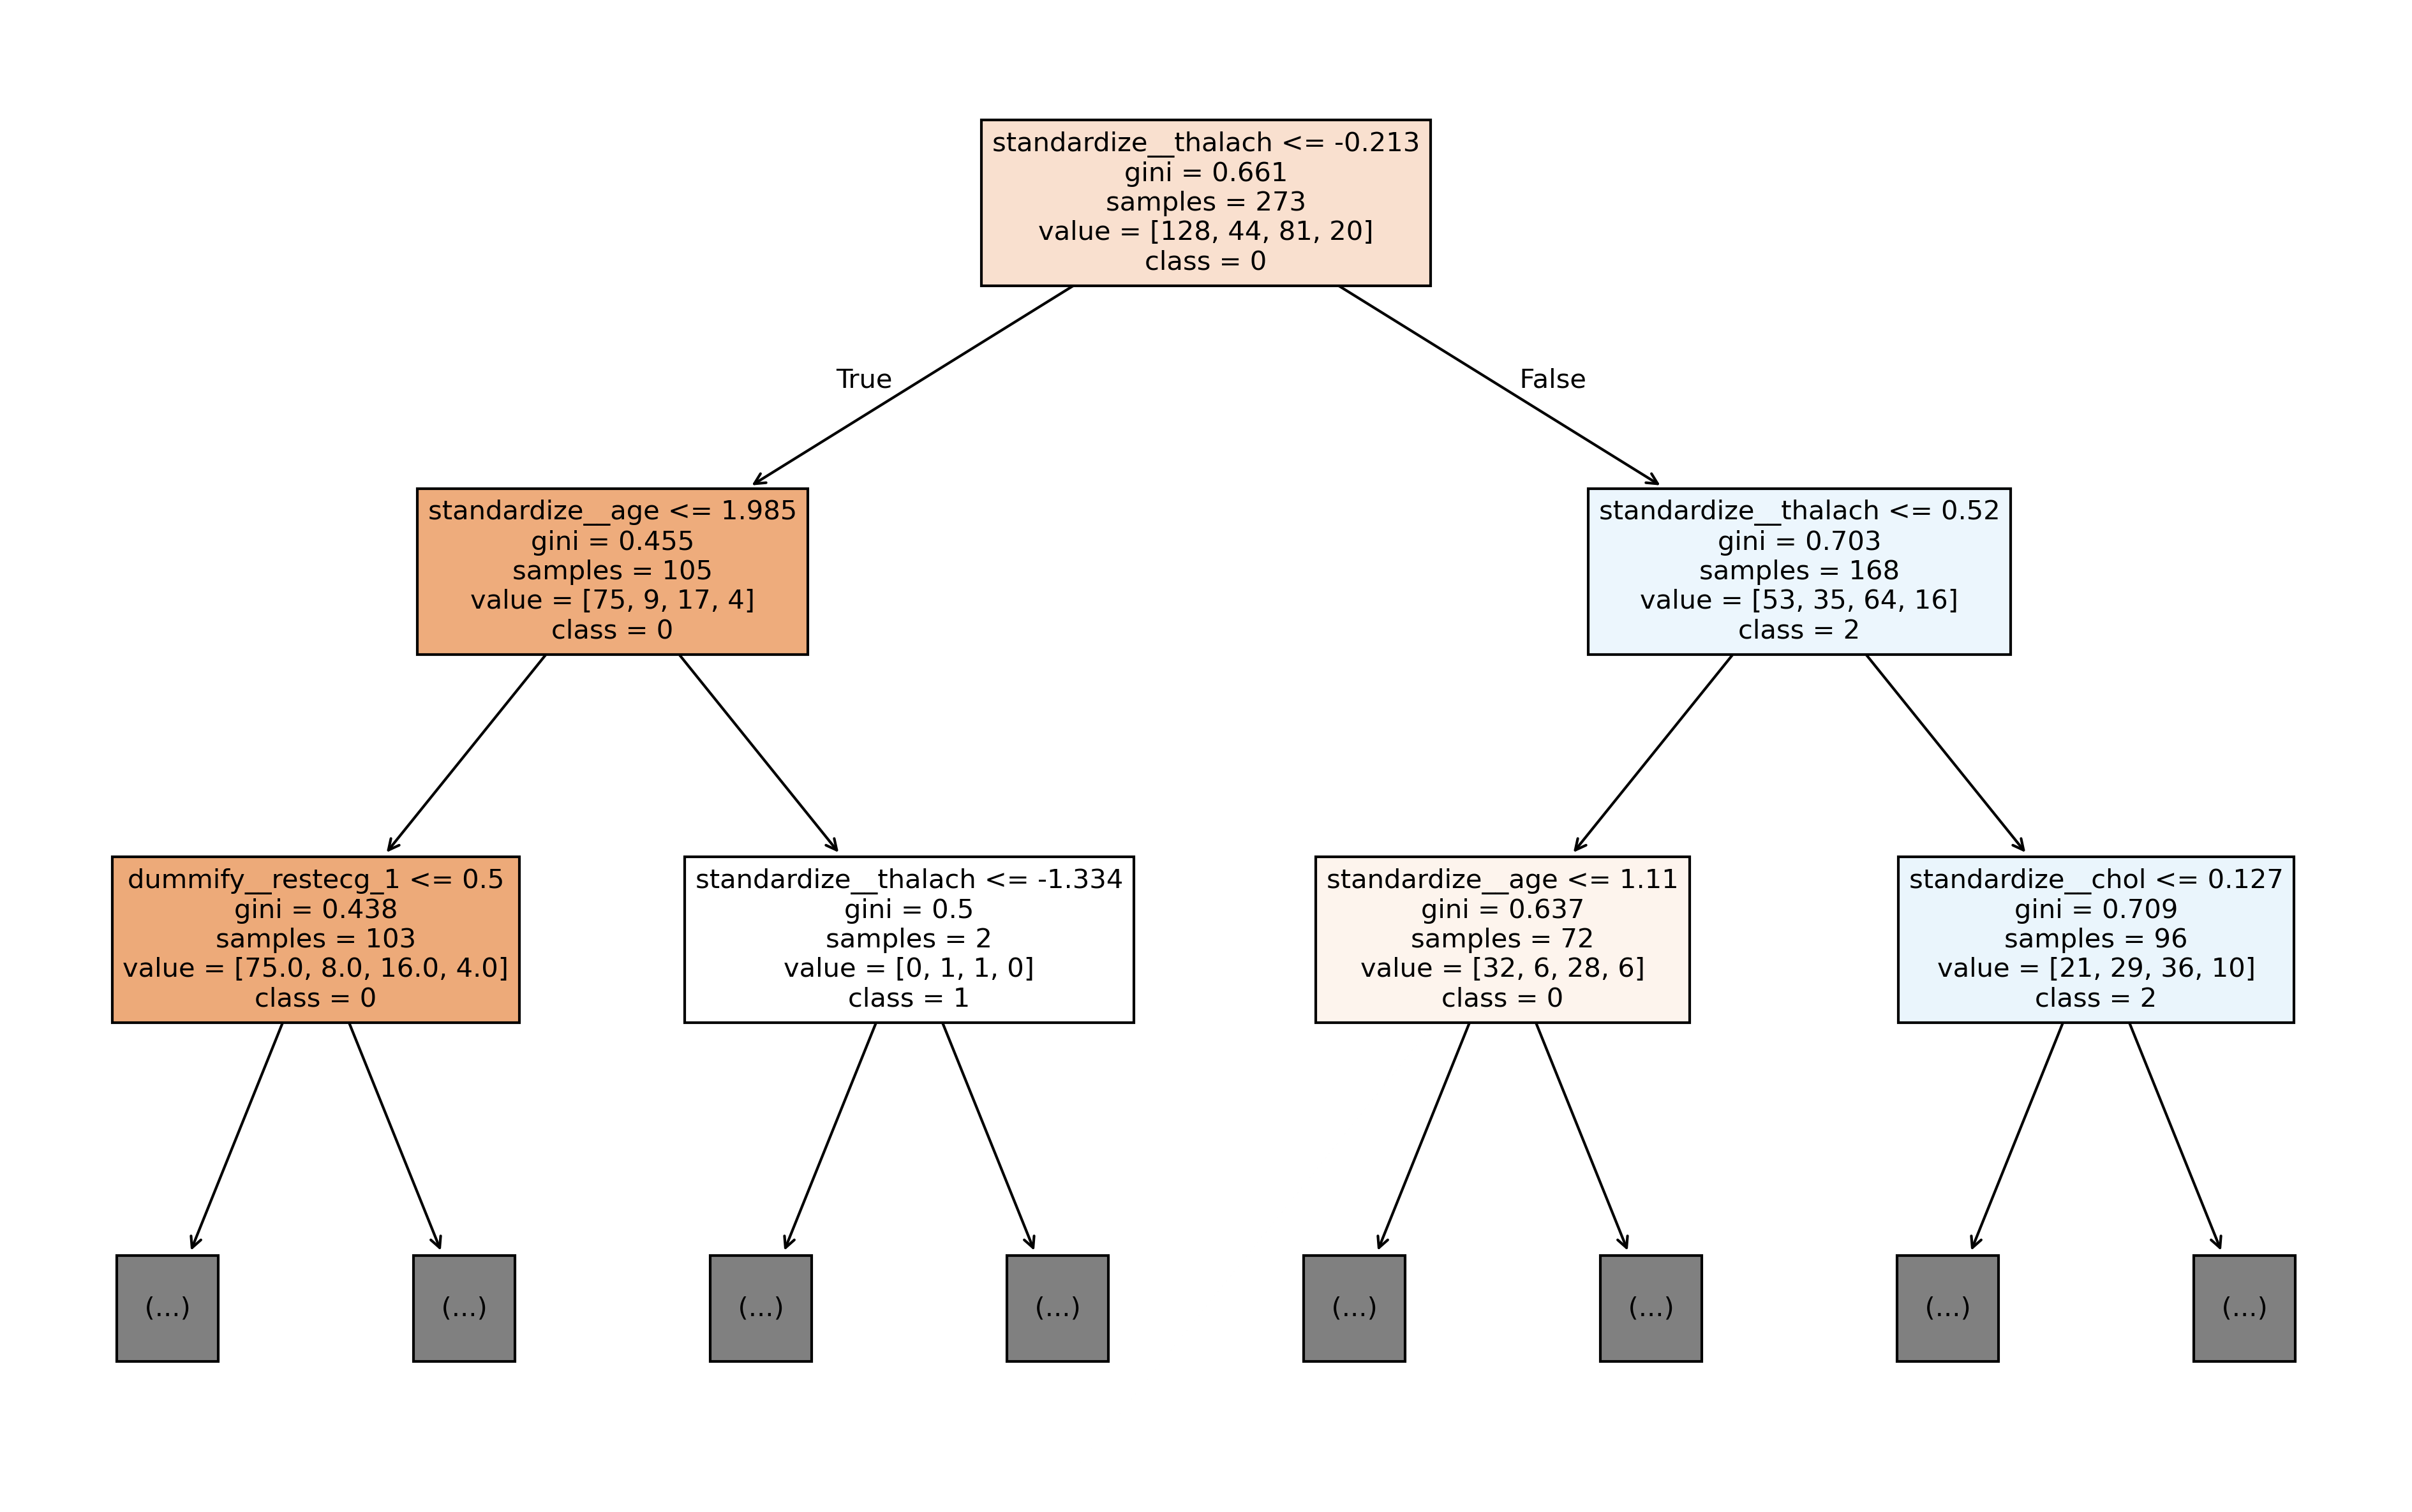

In [128]:
plt.figure(figsize=(16, 10), dpi = 300)
plot_tree(
    dt_pipeline.named_steps["decision_tree"],
    feature_names = dt_pipeline.named_steps["preprocessing"].get_feature_names_out(),
    class_names = dt_pipeline.named_steps["decision_tree"].classes_.astype(str),
    filled = True,
    fontsize = 10,
    max_depth = 2
)
plt.show()

### Model 3: LDA

In [129]:
# LDA Pipeline
lda_pipeline = Pipeline(
  [("preprocessing", ct),
  ("lda", LinearDiscriminantAnalysis())]
)

lda_pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'restecg']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('lda', LinearDiscriminantAnalysis())])

In [130]:
lda_score = cross_val_score(lda_pipeline, X, y,
                            cv = folds, scoring = "f1_macro").mean()
lda_score

np.float64(0.25641087960757)

## Q2:  OvR

Create a new column in the `ha` dataset called `cp_is_3`, which is equal to `1` if the `cp` variable is equal to `3` and `0` otherwise.

Then, fit a Logistic Regression to predict this new target, and report the **F1 Score**.

Repeat for the other three `cp` categories.  Which category was the OvR approach best at distinguishing?

In [131]:
ha2 = ha.copy()
ha2["cp_is_0"] = (ha2["cp"] == 0) * 1
ha2["cp_is_1"] = (ha2["cp"] == 1) * 1
ha2["cp_is_2"] = (ha2["cp"] == 2) * 1
ha2["cp_is_3"] = (ha2["cp"] == 3) * 1
ha2

,age,sex,cp,trtbps,chol,restecg,thalach,output,cp_is_0,cp_is_1,cp_is_2,cp_is_3
0,63,1,3,145,233,0,150,1,0,0,0,1
1,37,1,2,130,250,1,187,1,0,0,1,0
2,56,1,1,120,236,1,178,1,0,1,0,0
3,57,0,0,120,354,1,163,1,1,0,0,0
4,57,1,0,140,192,1,148,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
268,59,1,0,164,176,0,90,0,1,0,0,0
269,57,0,0,140,241,1,123,0,1,0,0,0
270,45,1,3,110,264,1,132,0,0,0,0,1
271,68,1,0,144,193,1,141,0,1,0,0,0


In [132]:
X2 = ha2.drop(["cp", "output", "cp_is_0", "cp_is_1", "cp_is_2", "cp_is_3"], axis = 1)
y2_cp0 = ha2["cp_is_0"]
y2_cp1 = ha2["cp_is_1"]
y2_cp2 = ha2["cp_is_2"]
y2_cp3 = ha2["cp_is_3"]

In [133]:
categorical_cols = ['sex', 'restecg']
numeric_cols = ['age', 'trtbps', 'chol', 'thalach']

In [134]:
ct = ColumnTransformer(
    [
        ("dummify",
         OneHotEncoder(drop='first',
                       sparse_output=False,
                       handle_unknown='ignore'),
         categorical_cols),

        ("standardize",
         StandardScaler(),
         numeric_cols)
    ],
    remainder="passthrough"
).set_output(transform="pandas")

In [135]:
logistic_pipeline = Pipeline(
  [("preprocessing", ct),
  ("logistic", LogisticRegression())]
)

In [136]:
logistic_pipeline.fit(X2, y2_cp0)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'restecg']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logistic', LogisticRegression())])

In [137]:
logistic_score_cp0 = cross_val_score(logistic_pipeline, X2, y2_cp0,
                            cv = folds, scoring = "f1_macro").mean()
logistic_score_cp0

np.float64(0.6437334560027631)

In [138]:
logistic_pipeline.fit(X2, y2_cp1)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'restecg']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logistic', LogisticRegression())])

In [139]:
logistic_score_cp1 = cross_val_score(logistic_pipeline, X2, y2_cp1,
                            cv = folds, scoring = "f1_macro").mean()
logistic_score_cp1

np.float64(0.45399819981998196)

In [140]:
logistic_pipeline.fit(X2, y2_cp2)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'restecg']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logistic', LogisticRegression())])

In [141]:
logistic_score_cp2 = cross_val_score(logistic_pipeline, X2, y2_cp2,
                            cv = folds, scoring = "f1_macro").mean()
logistic_score_cp2

np.float64(0.4238048163095602)

In [142]:
logistic_pipeline.fit(X2, y2_cp3)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'restecg']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logistic', LogisticRegression())])

In [143]:
logistic_score_cp3 = cross_val_score(logistic_pipeline, X2, y2_cp3,
                            cv = folds, scoring = "f1_macro").mean()
logistic_score_cp3

np.float64(0.47999861773446684)

## Q3: OvO

Reduce your dataset to only the `0` and `1` types of chest pain.

Then, fit a Logistic Regression to predict between the two groups, and report the **ROC-AUC**.  

Repeat comparing category `0` to `2` and `3`.  Which pair was the OvO approach best at distinguishing?

In [144]:
ha3 = ha.copy()
ha_01 = ha3[(ha3["cp"] == 0) | (ha3["cp"] == 1)]
ha_02 = ha3[(ha3["cp"] == 0) | (ha3["cp"] == 2)]
ha_03 = ha3[(ha3["cp"] == 0) | (ha3["cp"] == 3)]

In [145]:
X3_01 = ha_01.drop(["cp", "output"], axis = 1)
X3_02 = ha_02.drop(["cp", "output"], axis = 1)
X3_03 = ha_03.drop(["cp", "output"], axis = 1)
y3_01 = ha_01["cp"]
y3_02 = ha_02["cp"]
y3_03 = ha_03["cp"]

In [146]:
logistic_pipeline = Pipeline(
  [("preprocessing", ct),
  ("logistic", LogisticRegression())]
)

In [147]:
logistic_pipeline.fit(X3_01, y3_01)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'restecg']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logistic', LogisticRegression())])

In [148]:
logistic_score_01 = cross_val_score(logistic_pipeline, X3_01, y3_01,
                            cv = folds, scoring = "roc_auc").mean()
logistic_score_01

np.float64(0.7503931623931624)

In [149]:
logistic_pipeline.fit(X3_02, y3_02)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'restecg']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logistic', LogisticRegression())])

In [150]:
logistic_score_02 = cross_val_score(logistic_pipeline, X3_02, y3_02,
                            cv = folds, scoring = "roc_auc").mean()
logistic_score_02

np.float64(0.6839343891402715)

In [151]:
logistic_pipeline.fit(X3_03, y3_03)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'restecg']),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logistic', LogisticRegression())])

In [152]:
logistic_score_03 = cross_val_score(logistic_pipeline, X3_03, y3_03,
                            cv = folds, scoring = "roc_auc").mean()
logistic_score_03

np.float64(0.7649230769230769)